In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load COVID dataset
url = "https://raw.githubusercontent.com/SR1608/Datasets/main/covid-data.csv"
df = pd.read_csv(url)

In [11]:

print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nDataset Info:")
df.info()

pd.set_option('display.max_columns', None)
print("\nStatistical Summary:\n")
print(df.describe(include="all").round(2))

Dataset Shape: (57394, 49)

Data Types:
 iso_code                               object
continent                              object
location                               object
date                                   object
total_cases                           float64
new_cases                             float64
new_cases_smoothed                    float64
total_deaths                          float64
new_deaths                            float64
new_deaths_smoothed                   float64
total_cases_per_million               float64
new_cases_per_million                 float64
new_cases_smoothed_per_million        float64
total_deaths_per_million              float64
new_deaths_per_million                float64
new_deaths_smoothed_per_million       float64
reproduction_rate                     float64
icu_patients                          float64
icu_patients_per_million              float64
hosp_patients                         float64
hosp_patients_per_million             f

In [12]:
if 'location' in df.columns:
    print("\nUnique Locations:", df['location'].nunique())

if 'continent' in df.columns:
    print("\nContinent Counts:\n", df['continent'].value_counts())

if 'gdp_per_capita' in df.columns:
    print("\nMax GDP per Capita:", df['gdp_per_capita'].max())
    print("Mean GDP per Capita:", df['gdp_per_capita'].mean())

if 'total_cases' in df.columns:
    print("\nTotal Cases Quartiles:\n", df['total_cases'].quantile([0.25, 0.5, 0.75]))


Unique Locations: 216

Continent Counts:
 continent
Europe           14828
Africa           13637
Asia             13528
North America     9116
South America     3404
Oceania           2235
Name: count, dtype: int64

Max GDP per Capita: 116935.6
Mean GDP per Capita: 20620.172070879744

Total Cases Quartiles:
 0.25      180.00
0.50     2070.00
0.75    22356.75
Name: total_cases, dtype: float64


In [13]:
columns_to_keep = ['location', 'continent', 'date', 'total_cases', 'total_deaths', 'gdp_per_capita']
df = df[[col for col in columns_to_keep if col in df.columns]]


In [14]:

df = df.drop_duplicates()

print("\nMissing Values Before Cleaning:\n", df.isnull().sum())

for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(0)
    else:
        df[col] = df[col].fillna('Unknown')



Missing Values Before Cleaning:
 location              0
continent           646
date                  0
total_cases        3636
total_deaths      13026
gdp_per_capita     7027
dtype: int64


In [15]:

print("\nMissing Values After Cleaning:\n", df.isnull().sum())

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    print("\nDate Column Converted Successfully")


Missing Values After Cleaning:
 location          0
continent         0
date              0
total_cases       0
total_deaths      0
gdp_per_capita    0
dtype: int64

Date Column Converted Successfully


/tmp/ipython-input-2499329568.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


In [16]:

numeric_cols = df.select_dtypes(include='number').columns

df_groupby = df.groupby('continent')[numeric_cols].max().reset_index()
print("\nGrouped DataFrame:\n", df_groupby)


Grouped DataFrame:
        continent  total_cases  total_deaths  gdp_per_capita
0         Africa     752269.0       20314.0       26382.287
1           Asia    8874290.0      130519.0      116935.600
2         Europe    1991233.0       52147.0       94277.965
3  North America   11205486.0      247220.0       54225.446
4        Oceania      27750.0         907.0       44648.710
5  South America    5876464.0      166014.0       22767.037
6        Unknown   55154651.0     1328537.0       15469.207


In [17]:
if 'total_cases' in df_groupby.columns and 'gdp_per_capita' in df_groupby.columns:
    df_groupby['Cases_per_GDP'] = df_groupby['total_cases'] / (df_groupby['gdp_per_capita'] + 1)
    print("\nAfter Feature Engineering:\n", df_groupby)


After Feature Engineering:
        continent  total_cases  total_deaths  gdp_per_capita  Cases_per_GDP
0         Africa     752269.0       20314.0       26382.287      28.513089
1           Asia    8874290.0      130519.0      116935.600      75.889756
2         Europe    1991233.0       52147.0       94277.965      21.120650
3  North America   11205486.0      247220.0       54225.446     206.642456
4        Oceania      27750.0         907.0       44648.710       0.621505
5  South America    5876464.0      166014.0       22767.037     258.101478
6        Unknown   55154651.0     1328537.0       15469.207    3565.217388


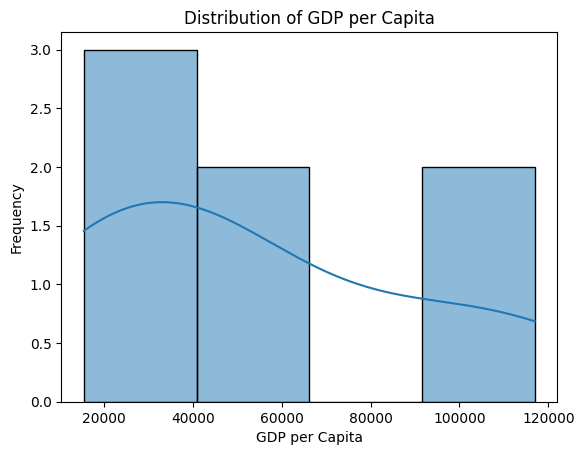

In [18]:
if 'gdp_per_capita' in df_groupby.columns:
    sns.histplot(df_groupby['gdp_per_capita'], kde=True)
    plt.title('Distribution of GDP per Capita')
    plt.xlabel('GDP per Capita')
    plt.ylabel('Frequency')
    plt.show()


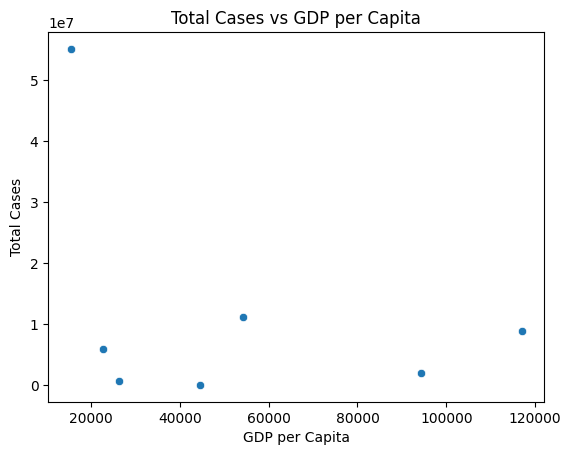

In [19]:
if 'total_cases' in df_groupby.columns and 'gdp_per_capita' in df_groupby.columns:
    sns.scatterplot(
        x='gdp_per_capita',
        y='total_cases',
        data=df_groupby
    )
    plt.title('Total Cases vs GDP per Capita')
    plt.xlabel('GDP per Capita')
    plt.ylabel('Total Cases')
    plt.show()


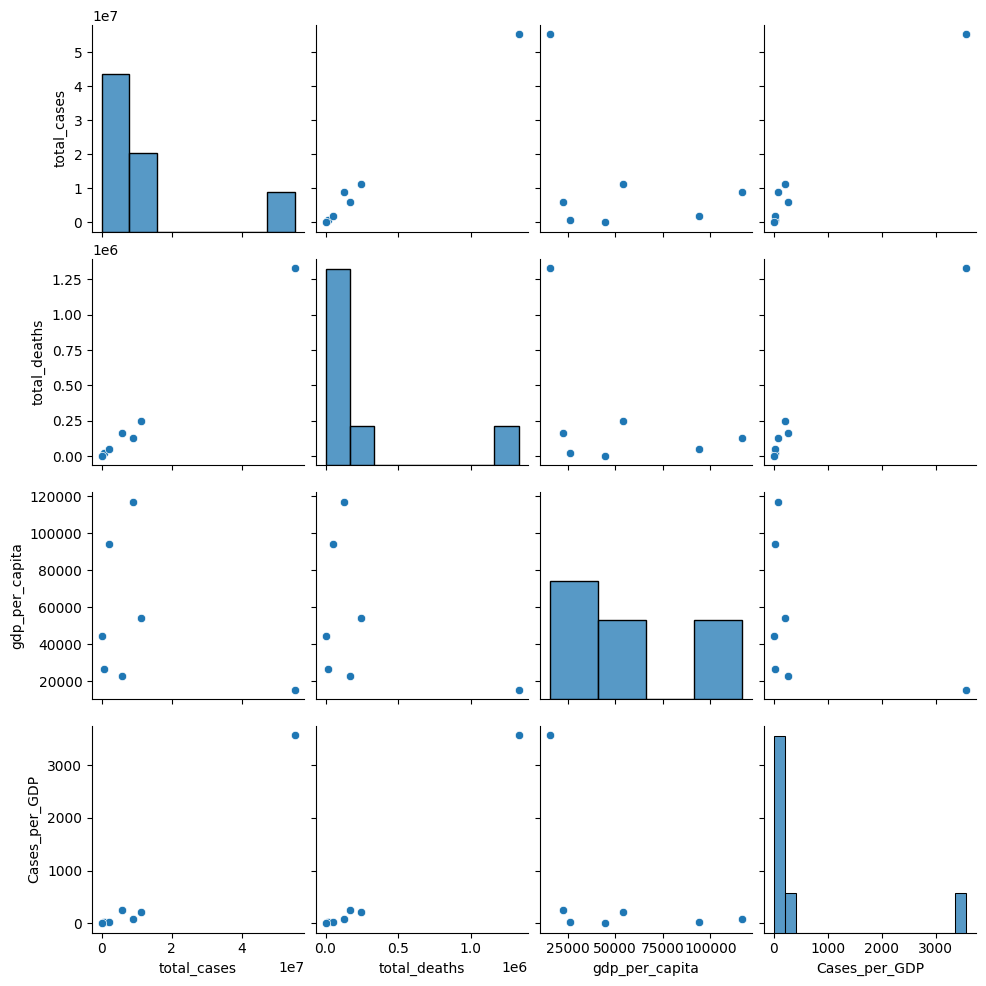

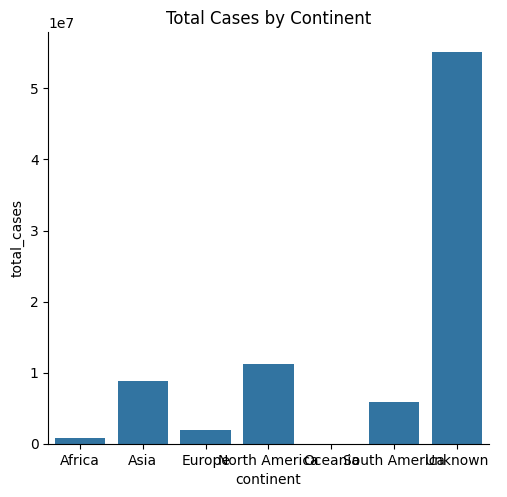

In [20]:
sns.pairplot(df_groupby)
plt.show()

if 'continent' in df_groupby.columns and 'total_cases' in df_groupby.columns:
    sns.catplot(
        x='continent',
        y='total_cases',
        data=df_groupby,
        kind='bar'
    )
    plt.title('Total Cases by Continent')
    plt.show()

In [21]:
df.to_csv("covid_Data.csv")